In [1]:
import numpy as np 
import rebound
import os
import matplotlib.pyplot as plt
import dill

In [2]:
tess_offset =  2457000

# Definitions

In [3]:
def mean_anomaly(t, omega, e, Tc, P):
    """
    Calculate mean anomaly M at time t, given:
    - omega: argument of periastron (radians)
    - e: eccentricity
    - Tc: time of inferior conjunction (transit)
    - P: orbital period
    
    Converts Tc to periastron passage time tau using the formula:
    2*pi*(Tc - tau)/P = E0 - e*sin(E0)
    with E0 = 2 * arctan(sqrt((1-e)/(1+e)) * tan(pi/2 - omega/2))
    
    Returns mean anomaly M in radians [0, 2pi).
    """
    # Compute E0 from e and omega
    E0 = 2 * np.arctan( np.sqrt((1 - e) / (1 + e)) * np.tan(np.pi/4 - omega/2) )
    E0 = E0 % (2 * np.pi)

    # Compute time of periastron passage tau
    tau = Tc - (P / (2 * np.pi)) * (E0 - e * np.sin(E0))
    # print(tau[0], omega[0], e[0], Tc[0], P[0] )
    # print(f'tau: {tau[0]}') 
    # print(f'omega: {omega[0]}')
    # print(f'e: {e[0]}')
    # print(f'Tc: {Tc[0]}')
    # print(f'P: {P[0]}')

    # Compute mean anomaly at time t
    M = (2 * np.pi / P) * (t - tau)
    M = M % (2 * np.pi)

    return M


# Data

In [4]:
### get the posterior data
file_name = '1339_jnkep_fit_1339-2000burn-2000step-emax0.5.pkl'

working_dir = os.getcwd()
data_dir = os.path.join(working_dir, "data")

file_path = os.path.join(data_dir, file_name)

In [5]:
with open(file_name, "rb") as f:
    mcmc = dill.load(f)
mcmc.print_summary()
print(mcmc)

posterior = mcmc.get_samples(group_by_chain=True)  # shape: (num_chains, num_samples, ...)
print({k: v.shape for k, v in posterior.items()})


                      mean       std    median      5.0%     95.0%     n_eff     r_hat
 ecosw_scaled[0]      0.33      0.07      0.32      0.23      0.41     23.37      1.17
 ecosw_scaled[1]      0.35      0.06      0.35      0.27      0.43     23.05      1.17
 esinw_scaled[0]      0.36      0.09      0.35      0.24      0.51     57.54      1.08
 esinw_scaled[1]      0.38      0.08      0.37      0.28      0.51     56.57      1.08
period_scaled[0]      0.50      0.00      0.50      0.50      0.50    262.42      1.04
period_scaled[1]      0.50      0.00      0.50      0.50      0.50   1759.29      1.00
 pmass_scaled[0]      0.02      0.00      0.02      0.01      0.02    535.57      1.02
 pmass_scaled[1]      0.01      0.00      0.01      0.01      0.01   1292.87      1.01
   tic_scaled[0]      0.48      0.00      0.48      0.48      0.49    117.37      1.04
   tic_scaled[1]      0.51      0.01      0.51      0.50      0.52   2171.55      1.00

Number of divergences: 749
{'ecc': (4, 20

In [6]:
good_chain_idxs = [0,1,2]

samples_filtered = {
    k: v[good_chain_idxs, ...] for k, v in posterior.items()
}
# print(samples_filtered)
samples = {
    k: v.reshape(-1, *v.shape[2:]) for k, v in samples_filtered.items()
}

# Shape of samples
print({k: v.shape for k, v in samples.items()})


{'ecc': (6000, 2), 'ecosw': (6000, 2), 'ecosw_scaled': (6000, 2), 'ediff': (6000,), 'esinw': (6000, 2), 'esinw_scaled': (6000, 2), 'period': (6000, 2), 'period_scaled': (6000, 2), 'pmass': (6000, 2), 'pmass_scaled': (6000, 2), 'tcmodel': (6000, 39), 'tic': (6000, 2), 'tic_scaled': (6000, 2)}


In [7]:
### conversions
solar_mass_2_kg = 1.989e30 # [kg per solar mass]
d_2_s = 86400 # [seconds per day]

### system constants 
m_star = 0.81  # [solar mass]

from astropy import units as u
from astropy import constants as c
G_const_si = c.G
G_const = c.G.to(u.AU**3 / u.M_sun / u.day**2).value


### posterior samples 
ecosw_b = samples["ecosw"][:, 0]
esinw_b = samples["esinw"][:, 0]
# e_b = samples["ecc"][:,0]
P_b = samples["period"][:,0] # [days]
Tc_b = samples["tic"][:,0] # [days]
m_b = samples["pmass"][:,0] # [solar mass]

ecosw_c = samples["ecosw"][:, 1]
esinw_c = samples["esinw"][:, 1]
# e_c = samples["ecc"][:,1]
P_c = samples["period"][:,1] # [days]
Tc_c = samples["tic"][:,1] # [days]
m_c = samples["pmass"][:,1] # [solar mass]  

### calculated params
a_b = np.array(((G_const*m_star*P_b**2)/(4*np.pi**2))**(1.0/3)) # [AU]
a_c = np.array(((G_const*m_star*P_c**2)/(4*np.pi**2))**(1/3)) # [AU]

e_b = np.sqrt(ecosw_b**2 + esinw_b**2)
e_c = np.sqrt(ecosw_c**2 + esinw_c**2)
omega_b = np.arctan2(esinw_b, ecosw_b) # [rad]
omega_c = np.arctan2(esinw_c, ecosw_c) # [rad]

# times = np.array([1980.] * len(omega_b))
times = Tc_c

Mean_anomaly_b = mean_anomaly(times, omega_b, e_b, Tc_b, P_b)
Mean_anomaly_c = mean_anomaly(times, omega_c, e_c, Tc_c, P_c)

### keep Omega constant
value_Omega_b = 0  # [deg]
Omega_b = np.full_like(omega_b, np.radians(value_Omega_b))
value_Omega_c = 0 # [deg]
Omega_c = np.full_like(omega_c, np.radians(value_Omega_c))

pomega_b = omega_b + Omega_b
pomega_c = omega_c + Omega_c
lambda_b = omega_b + Omega_b + Mean_anomaly_b
lambda_c = omega_c + Omega_c + Mean_anomaly_c

# Set fixed inclination (e.g. edge-on)
inc_b = [np.pi / 2] * len(a_b)
inc_c = [np.pi / 2] * len(a_c)

print(a_b)
print(m_b)
print(np.array(Omega_b))

[0.17053384 0.17053425 0.17053446 ... 0.17053504 0.17053458 0.17053431]
[1.72194686e-05 1.86735215e-05 1.46411703e-05 ... 1.23639875e-05
 1.28006832e-05 1.42842500e-05]
[0. 0. 0. ... 0. 0. 0.]


In [ ]:
# Set parameters (fixed values from literature) Polanski, orell-miquel
from astropy.constants import M_jup, M_sun
mass_a = 0.0302 * (M_jup / M_sun)
a_a = 0.079
e_a = 0.0
omega_a = np.radians(90.)
Omega_a = 0.0 # assume 0
inc_a = np.pi / 2
Tc_a = 2458715.35572 - tess_offset
P_a = 8.8803232



mass_d = 0.000337  # MJup to Msun
a_d = 0.400
e_d = 0.0
omega_d = np.radians(230.0)
Omega_d = 0.0  # Assume 0 for simplicity
inc_d = np.pi / 2  # edge-on
Tc_d = 2459044.0 - tess_offset
P_d = 101.5

# Reference time = same as for other planets
# t_ref = times[i]  # or pick a fixed time like 2459000

M_d = mean_anomaly(np.median(Tc_c), omega_d, e_d, Tc_d, P_d)
M_a = mean_anomaly(np.median(Tc_c), omega_a, e_a, Tc_a, P_a)

# Check stability
only return true if no encounter, escape, or exception

In [12]:
def simulate_draw(i, m_star, a_b, a_c, m_b, m_c, e_b, e_c, inc_b, inc_c,
                  Omega_b, Omega_c, omega_b, omega_c, M_b, M_c,
                  tmax=1e6, dt=0.05):
    """
    Simulate a single posterior draw for two planets and return True if stable.
    Assumes units: AU, Msun, days.
    """
    sim = rebound.Simulation()
    sim.units = ('AU', 'day', 'Msun')
    sim.G = G_const  # Set your custom G if using AU/day²/Msun

    # Central star
    sim.add(m=m_star)

    # Planet b
    sim.add(m=mass_a,
        a=a_a,
        e=e_a,
        inc=inc_a,
        Omega=Omega_a,
        omega=omega_a,
        M=M_a)

    # Planet c
    sim.add(m=m_b[i],
            a=a_b[i],
            e=e_b[i],
            inc=inc_b[i],
            Omega=Omega_b[i],
            omega=omega_b[i],
            M=M_b[i])

    # Planet d
    sim.add(m=m_c[i],
            a=a_c[i],
            e=e_c[i],
            inc=inc_c[i],
            Omega=Omega_c[i],
            omega=omega_c[i],
            M=M_c[i])

    # Planet e
    sim.add(m=mass_d,
        a=a_d,
        e=e_d,
        inc=inc_d,
        Omega=Omega_d,
        omega=omega_d,
        M=M_d)

    
    sim.move_to_com()
    sim.integrator = "whfast"
    sim.dt = dt

    # Optional: encounter detection
    sim.exit_min_distance = 0.01  # [AU], or adjust to Roche limit

    try:
        Noutputs = 6000  # number of points along orbit

        # arrays to store positions
        Nplanets = len(sim.particles) - 1  # skip star
        x = np.zeros((Noutputs, Nplanets))
        y = np.zeros((Noutputs, Nplanets))
        e = np.zeros((Noutputs, Nplanets))
        a = np.zeros((Noutputs, Nplanets))
        # choose times: 0 → tmax
        times = np.linspace(0, tmax, Noutputs)
        # dt_output = times[1] - times[0]
        
        for i, t in enumerate(times):
            # sim.integrate(sim.t + dt_output)
            sim.integrate(t)#, exact_finish_time=0)
            for j in range(Nplanets):
                p = sim.particles[j+1]  # skip star at index 0
                x[i,j] = p.x
                y[i,j] = p.z  # because of inclination
                e[i,j] = p.e
                a[i,j] = p.a
                
        sim.integrate(tmax)

        
        if (e[:,0] >= 1.0).any() or (e[:,1] >= 1.0).any() or (e[:,2]>=1.0).any() or (e[:,3]>= 1.0).any():
            note = "escape or unbound"
            print(note)
            return False, note, sim, x, y, e, a

        # Q_b = b_elem['a'] * (1 + b_elem['e'])
        # q_c = c_elem['a'] * (1 - c_elem['e'])
        for i in range(Noutputs):
            Q_b = a[i,1] * (1 + e[i,1])
            q_c = a[i,2] * (1 - e[i,2])
            
            if q_c < Q_b:
                note = "orbit crossing"
                print(note)
                return False, note, sim, x, y, e, a
                
        note='stable'
        print(note)
        return True, note, sim, x, y, e, a

    except rebound.Encounter:
        note = f"encounter"
        print(note)
        return False, note, sim, x, y, e, a
    


In [10]:
n_draws = 20  # or whatever number feels fast enough
N_total = len(P_b)  # assuming all arrays are same length

# Choose `n_draws` unique random indices
random_indices = np.random.choice(N_total, size=n_draws, replace=False)


28580757.14111328
encounter


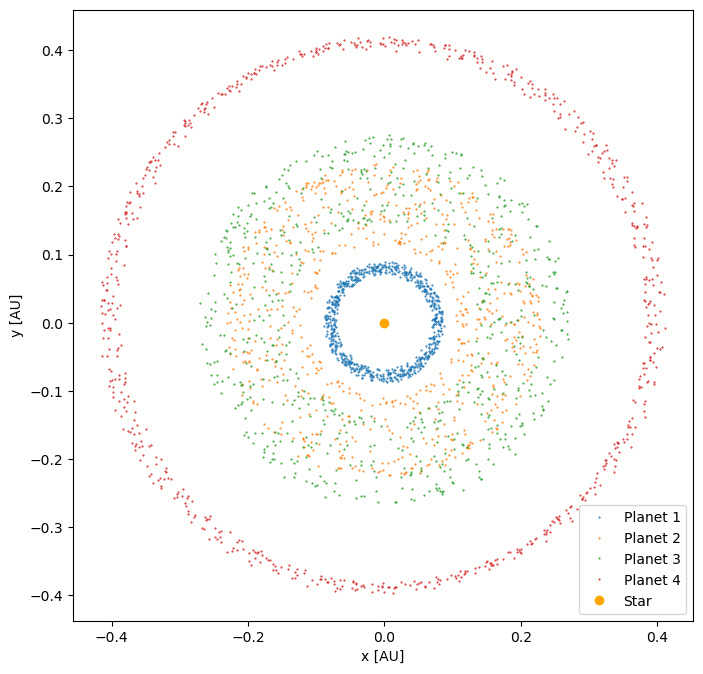

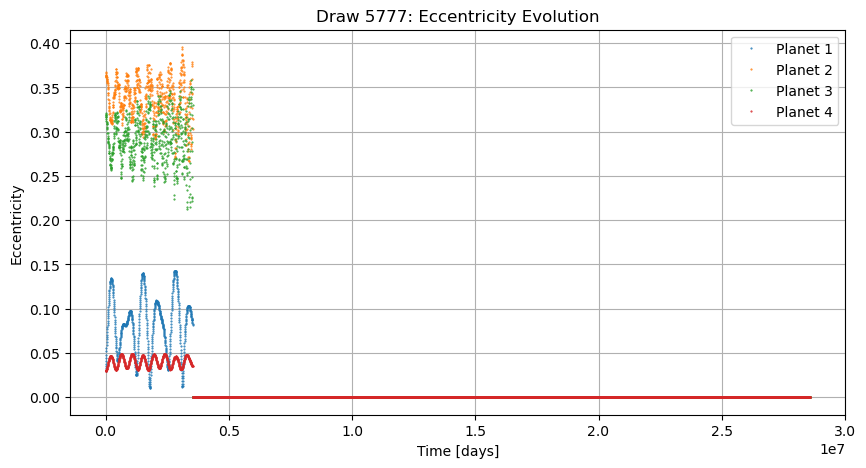

6000
stable


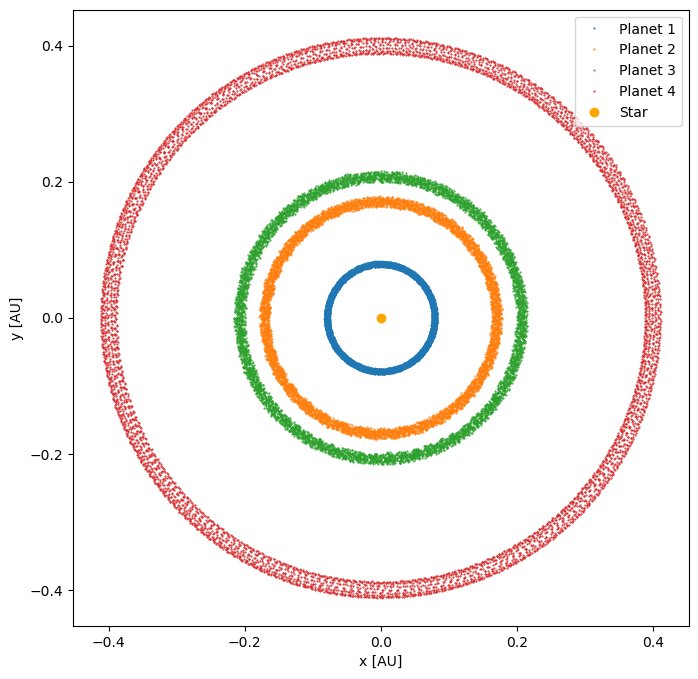

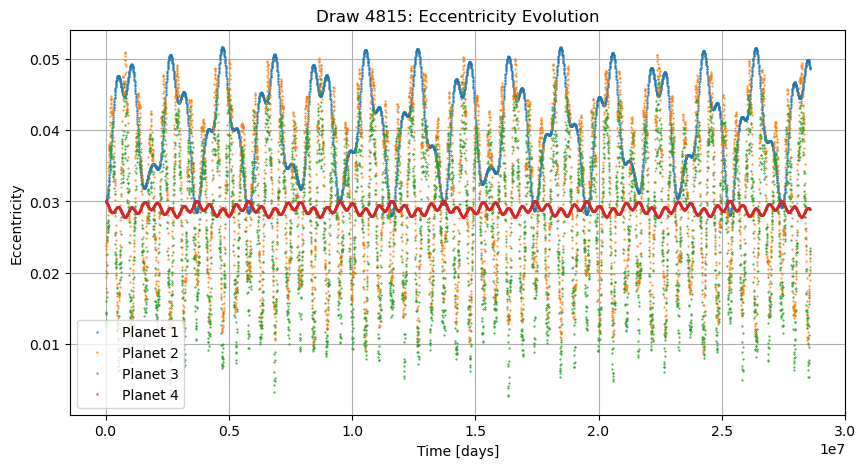

6000
orbit crossing


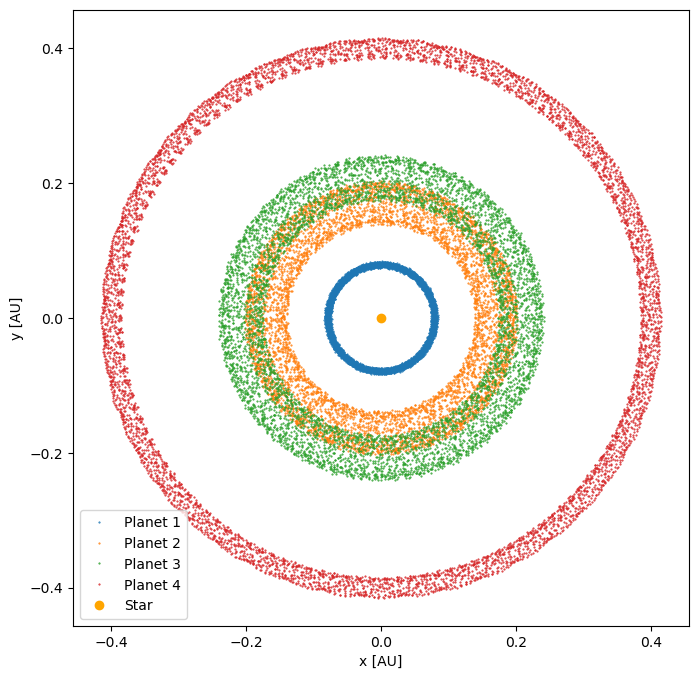

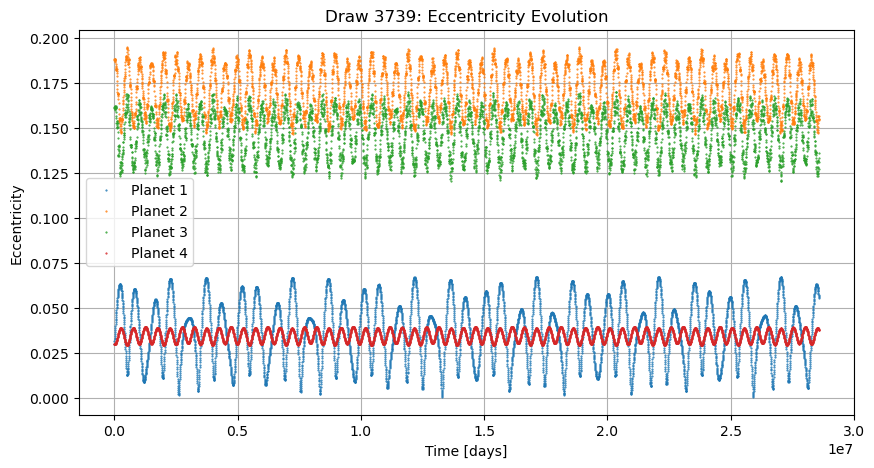

6000
orbit crossing


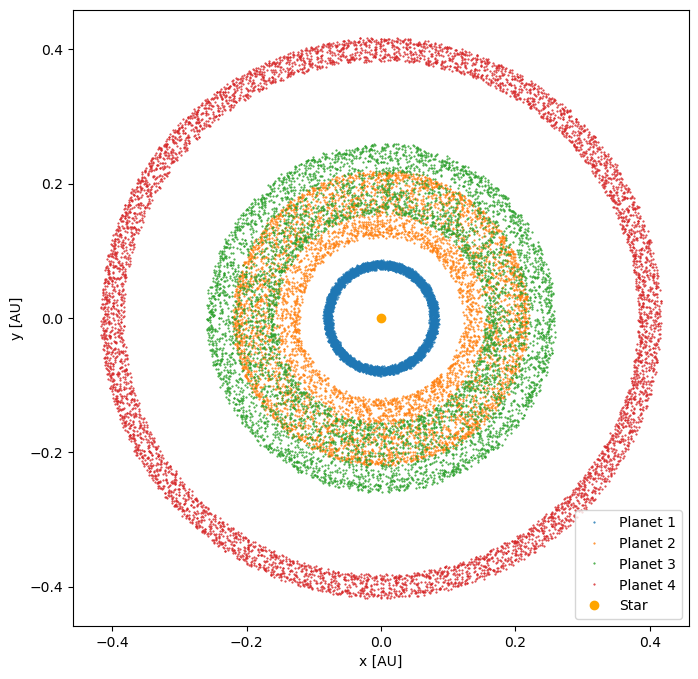

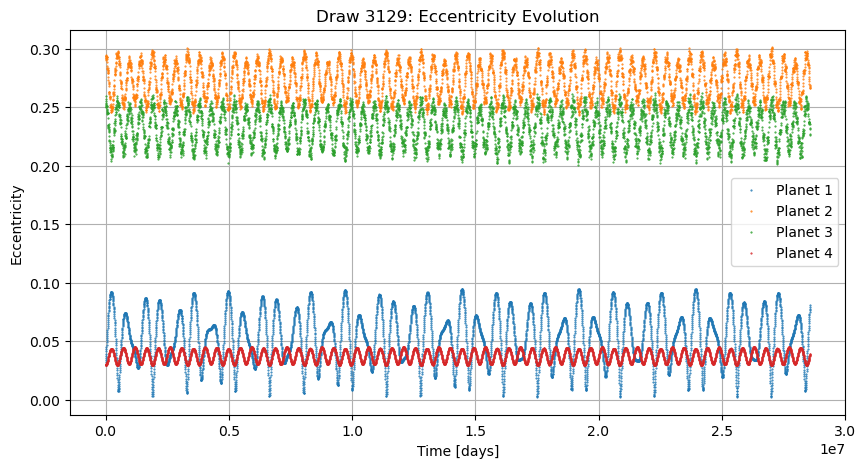

6000
stable


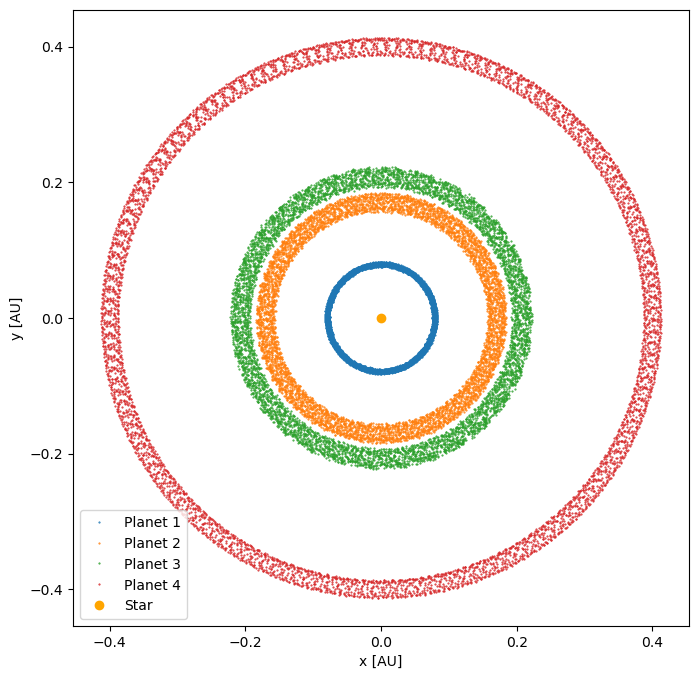

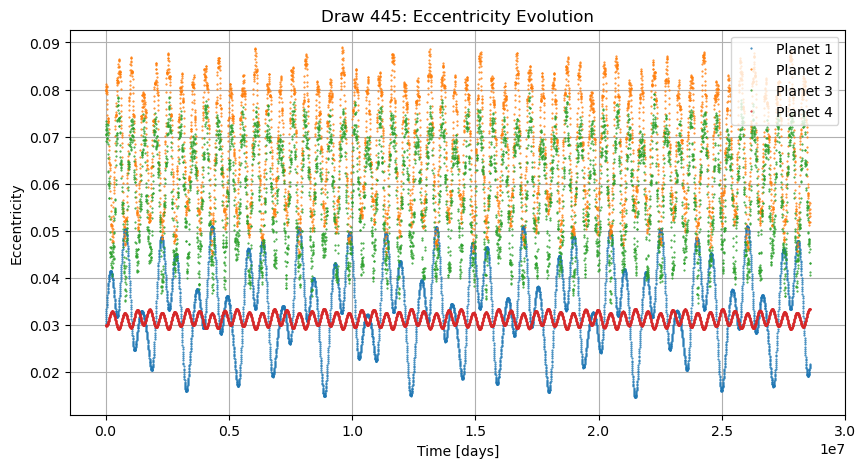

6000
orbit crossing


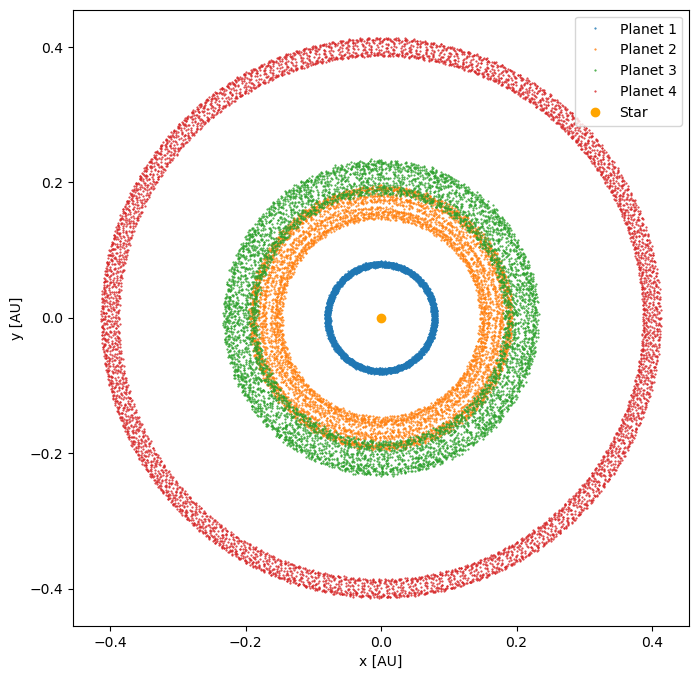

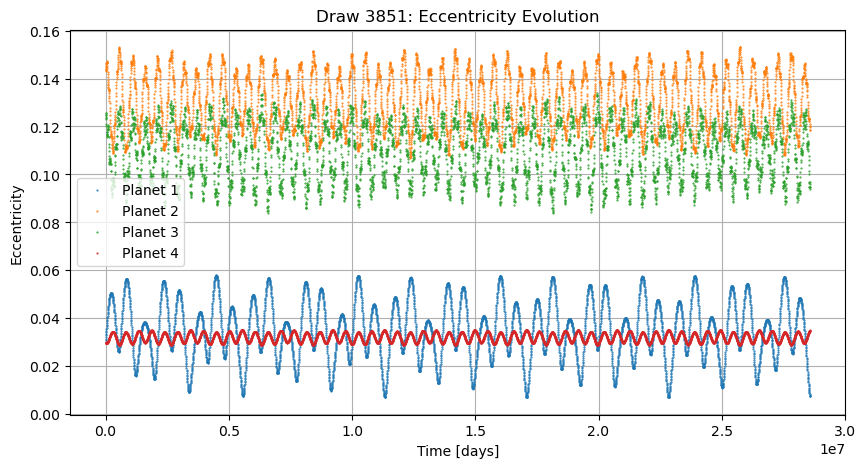

6000
orbit crossing


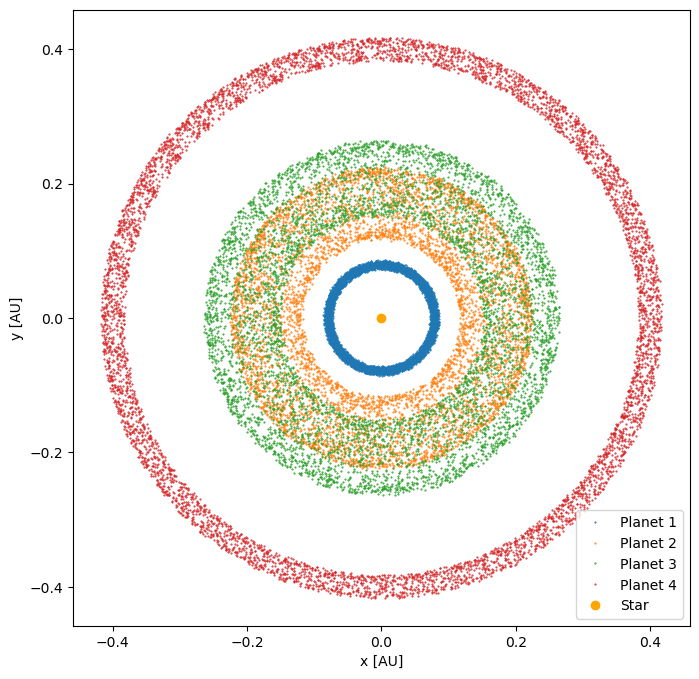

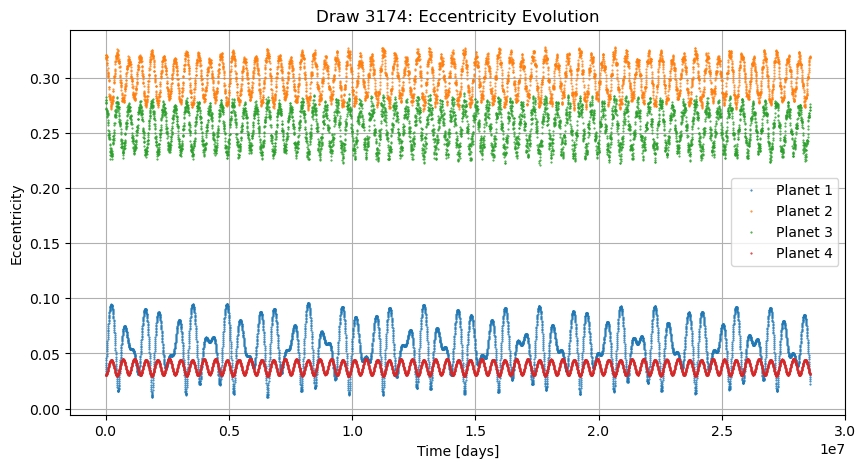

6000


In [ ]:
tmax = 1e6 * np.median(P_b)
print(tmax)
draw_idx = []
results = []
notes = []
sims = []
for i in random_indices:
    stable, note, sim, x, y, e, a = simulate_draw(
        i=i,
        m_star=m_star,
        a_b=a_b, a_c=a_c,
        m_b=m_b, m_c=m_c,
        e_b=e_b, e_c=e_c,
        inc_b=inc_b, inc_c=inc_c,
        Omega_b=Omega_b, Omega_c=Omega_c,
        omega_b=omega_b, omega_c=omega_c,
        M_b=Mean_anomaly_b, M_c=Mean_anomaly_c,
        tmax = tmax
    )
    draw_idx.append(i)
    results.append(stable)
    notes.append(note)
    sims.append(sim)
    # rebound.OrbitPlotSet(sim)
    
    # orbit plot
    plt.figure(figsize=(8,8))
    Nplanets = len(sim.particles) - 1  # skip star
    for j in range(Nplanets):
        plt.plot(x[:,j], y[:,j], '.', markersize=1, label=f'Planet {j+1}')
    plt.plot(0,0,'o', color='orange', label='Star')
    plt.gca().set_aspect('equal', 'box')
    plt.xlabel('x [AU]')
    plt.ylabel('y [AU]')
    plt.legend()
    plt.show()

    # eccentricity plot 
    # --- Eccentricity evolution plot ---
    plt.figure(figsize=(10,5))
    times = np.linspace(0, tmax, 6000)
    for j in range(Nplanets):
        plt.plot(times, e[:,j], '.', markersize=1, label=f'Planet {j+1}')
    plt.xlabel('Time [days]')
    plt.ylabel('Eccentricity')
    plt.title(f"Draw {i}: Eccentricity Evolution")
    plt.legend()
    plt.grid(True)
    plt.show()
    # print(len(e))
    

    # plot_orbits(sim, labels=["Star", "Planet 2", "Planet 3", "Planet 4"], show_trajectory=True)
    # plot_system_faceon(sim, labels=["Star", "Planet b", "Planet c", "Planet d"])

print(results)
print(notes)
print(draw_idx)

In [ ]:
stable_count = sum(results)
total = len(results)
stable_fraction = stable_count / total
print(f"Fraction of stable posterior draws: {stable_fraction:.2f}")
print(f"{stable_count} stable of {total} total systems")

In [ ]:
true_indices = [i for i, val in enumerate(results) if val]

draws = [draw_idx[i] for i in true_indices]
for draw in draws:
    m2=m_b[draw]
    a2=a_b[draw]
    e2=e_b[draw]
    inc2=inc_b[draw]
    Omega2=Omega_b[draw]            
    omega2=omega_b[draw]
    M2=Mean_anomaly_b[draw]

    # Planet d
    m3=m_c[draw]
    a3=a_c[draw]
    e3=e_c[draw]
    inc3=inc_c[draw]
    Omega3=Omega_c[draw]
    omega3=omega_c[draw]
    M3=Mean_anomaly_c[draw]

    print(f'ecc 2: {e2}')
    print(f'ecc 3: {e3}')
    print('\n')


In [ ]:
# all orbit draw eccentricities 
for draw in draw_idx:
    m2=m_b[draw]
    a2=a_b[draw]
    e2=e_b[draw]
    inc2=inc_b[draw]
    Omega2=Omega_b[draw]            
    omega2=omega_b[draw]
    M2=Mean_anomaly_b[draw]

    # Planet d
    m3=m_c[draw]
    a3=a_c[draw]
    e3=e_c[draw]
    inc3=inc_c[draw]
    Omega3=Omega_c[draw]
    omega3=omega_c[draw]
    M3=Mean_anomaly_c[draw]

    print(f'ecc 2: {e2}')
    print(f'ecc 3: {e3}')
    print('\n')


